# CS274P Project
**Main method in this notebook:** Recursive Neural Network (RecNN) sequence-to-sequence model.

- **Dataset:** USPTO-MIT reaction SMILES
- **Input:** reactants/reagents SMILES
- **Output:** product SMILES
- **Baseline/comparison:** character-level Transformer seq2seq model
- **Main proposed method:** Recursive Neural Network encoder + autoregressive decoder
- **Experiment tracking:** optional Weights & Biases (WandB) and/or TensorBoard logging
- **Hyperparameter tuning:** small manual sweep over learning rate, hidden size, dropout, and batch size

The default settings are intentionally small so the notebook can run as a sanity check. For project-quality results, change `RUN_MODE` from `"smoke"` to `"medium"` or run the hyperparameter sweep on a larger subset.


## update: hyperparameter tuning + chemical-equivalence evaluation

1. **Ray Tune hyperparameter tuning** over learning rate, dropout, and batch size.
2. **Chemical-equivalence accuracy** using RDKit canonicalization, so equivalent SMILES forms can be counted as correct instead of relying only on raw string exact match.

Recommended order: run data/model setup cells first, run the Ray Tune section, train the final tuned model, then run greedy decoding + chemical-equivalence evaluation for the slide table.


## 1. Imports and project paths

In [1]:
from pathlib import Path
import json
import math
import random
import re
import time
import zipfile
from collections import Counter
from dataclasses import dataclass
from typing import Optional, Tuple, Dict, Any, List

import numpy as np
import pandas as pd
import requests
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw" / "uspto_mit"
PROCESSED_DIR = DATA_DIR / "processed" / "uspto_mit"
OUTPUT_DIR = PROJECT_DIR / "outputs" / "uspto_mit_recursive_nn"
BASELINE_OUTPUT_DIR = PROJECT_DIR / "outputs" / "uspto_mit_transformer_baseline"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BASELINE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Raw data directory:", RAW_DIR)
print("Processed data directory:", PROCESSED_DIR)
print("Recursive NN output directory:", OUTPUT_DIR)
print("Transformer baseline output directory:", BASELINE_OUTPUT_DIR)


d:\anaconda3\envs\torchfix\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project directory: c:\Users\XQH\Desktop\274P project updated
Raw data directory: c:\Users\XQH\Desktop\274P project updated\data\raw\uspto_mit
Processed data directory: c:\Users\XQH\Desktop\274P project updated\data\processed\uspto_mit
Recursive NN output directory: c:\Users\XQH\Desktop\274P project updated\outputs\uspto_mit_recursive_nn
Transformer baseline output directory: c:\Users\XQH\Desktop\274P project updated\outputs\uspto_mit_transformer_baseline


## 2. Reproducibility and device selection

In [2]:
SEED = 274


def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # These settings improve reproducibility. They can make training slightly slower.
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


def pick_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


set_seed(SEED)
DEVICE = pick_device()
print("Using device:", DEVICE)


Using device: cuda


## 3. Download USPTO-MIT

In [3]:
USPTO_MIT_URL = "https://github.com/wengong-jin/nips17-rexgen/raw/master/USPTO/data.zip"
zip_path = RAW_DIR / "data.zip"


def download_file(url: str, dest: Path):
    if dest.exists() and dest.stat().st_size > 0:
        print(f"Already exists: {dest}")
        return

    print(f"Downloading from {url}")
    response = requests.get(url, stream=True, timeout=60)
    response.raise_for_status()

    total = int(response.headers.get("content-length", 0))
    with open(dest, "wb") as f, tqdm(total=total, unit="B", unit_scale=True) as pbar:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
                pbar.update(len(chunk))
    print(f"Saved to {dest}")


download_file(USPTO_MIT_URL, zip_path)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(RAW_DIR)

print("Extracted files:")
for path in sorted(RAW_DIR.rglob("*"))[:50]:
    print(" -", path.relative_to(RAW_DIR))

Already exists: c:\Users\XQH\Desktop\274P project updated\data\raw\uspto_mit\data.zip
Extracted files:
 - data
 - data\test.txt
 - data\train.txt
 - data\valid.txt
 - data.zip


## 4. Inspect the extracted files

The expected split files are usually `train.txt`, `dev.txt`, and `test.txt`.  
This cell searches recursively so the notebook still works if the files are nested.

In [4]:
txt_files = sorted(RAW_DIR.rglob("*.txt"))
file_info = []
for p in txt_files:
    try:
        size_mb = p.stat().st_size / (1024 ** 2)
        with open(p, "r", encoding="utf-8", errors="ignore") as f:
            first_line = f.readline().strip()
        file_info.append({
            "path": str(p.relative_to(RAW_DIR)),
            "size_mb": round(size_mb, 2),
            "first_line_preview": first_line[:120],
        })
    except Exception as e:
        file_info.append({"path": str(p.relative_to(RAW_DIR)), "error": str(e)})

pd.DataFrame(file_info)

,path,size_mb,first_line_preview
0,data\test.txt,18.60,[CH2:23]1[O:24][CH2:25][CH2:26][CH2:27]1.[F:1]...
1,data\train.txt,189.95,[CH2:15]([CH:16]([CH3:17])[CH3:18])[Mg+:19].[C...
2,data\valid.txt,13.90,[CH3:15][C:16](=[O:17])[CH3:18].[CH3:3][O:4][c...


## 5. Prepare reaction pairs

We convert each reaction into:

```text
source = reactants/reagents
target = product
```

For a first sequence-to-sequence baseline, we remove atom-map numbers like `:12` in `[CH3:12]`. This makes the model focus on product SMILES prediction rather than copying atom-mapping labels.


In [5]:
ATOM_MAP_RE = re.compile(r":\d+(?=\])")


def strip_atom_mapping(smiles: str) -> str:
    """Remove atom-map numbers like [CH3:12] -> [CH3]."""
    return ATOM_MAP_RE.sub("", smiles)


def split_reaction_smiles(rxn: str) -> Optional[Tuple[str, str]]:
    """
    Convert reaction SMILES to (source, target).

    Handles:
    - reactants>>products
    - reactants>reagents>products
    """
    rxn = rxn.strip()

    if ">>" in rxn:
        left, product = rxn.split(">>", 1)
        source = left
    else:
        parts = rxn.split(">")
        if len(parts) != 3:
            return None
        reactants, reagents, product = parts
        source = reactants if reagents == "" else f"{reactants}>{reagents}"

    source = source.strip()
    product = product.strip()

    if not source or not product:
        return None
    return source, product


def find_split_file(raw_dir: Path, split: str) -> Path:
    """Find train/dev/test split file recursively."""
    aliases = {
        "train": ["train"],
        "valid": ["valid", "validation", "dev"],
        "test": ["test"],
    }[split]

    candidates = []
    for p in raw_dir.rglob("*.txt"):
        name = p.name.lower()
        stem = p.stem.lower()
        if any(a == stem or a in name for a in aliases):
            candidates.append(p)

    if not candidates:
        raise FileNotFoundError(
            f"Could not find split={split}. Available txt files: {[str(p.relative_to(raw_dir)) for p in raw_dir.rglob('*.txt')]}"
        )

    # Prefer exact train.txt/dev.txt/test.txt names.
    for alias in aliases:
        for p in candidates:
            if p.name.lower() == f"{alias}.txt":
                return p

    # Otherwise choose the largest matching file.
    return max(candidates, key=lambda p: p.stat().st_size)


split_paths = {
    "train": find_split_file(RAW_DIR, "train"),
    "valid": find_split_file(RAW_DIR, "valid"),
    "test": find_split_file(RAW_DIR, "test"),
}

for split, path in split_paths.items():
    print(split, "->", path.relative_to(RAW_DIR))

train -> data\train.txt
valid -> data\valid.txt
test -> data\test.txt


In [6]:
def iter_pairs(path: Path, strip_maps: bool = True, limit: Optional[int] = None):
    """
    Read USPTO-MIT lines.

    Jin/MIT format has at least:
        reaction_smiles reaction_center_metadata

    We take the first whitespace-separated field as reaction SMILES.
    """
    n = 0
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in tqdm(f, desc=f"Reading {path.name}"):
            line = line.strip()
            if not line:
                continue

            rxn = line.split()[0]
            pair = split_reaction_smiles(rxn)
            if pair is None:
                continue

            src, tgt = pair
            if strip_maps:
                src = strip_atom_mapping(src)
                tgt = strip_atom_mapping(tgt)

            yield src, tgt

            n += 1
            if limit is not None and n >= limit:
                break


# Preview examples.
examples = list(iter_pairs(split_paths["train"], strip_maps=True, limit=5))
for i, (src, tgt) in enumerate(examples, 1):
    print(f"Example {i}")
    print("SRC:", src[:200])
    print("TGT:", tgt[:200])
    print()

Reading train.txt: 4it [00:00, ?it/s]

Example 1
SRC: [CH2]([CH]([CH3])[CH3])[Mg+].[CH2]1[O][CH2][CH2][CH2]1.[Cl-].[OH][c]1[n][cH][c]([C](=[O])[N]([O][CH3])[CH3])[cH][cH]1
TGT: [OH][c]1[n][cH][c]([C](=[O])[CH2][CH]([CH3])[CH3])[cH][cH]1

Example 2
SRC: [CH3][NH2].[N+](=[O])([O-])[c]1[cH][c]([C](=[O])[OH])[cH][cH][c]1[Cl].[OH2]
TGT: [N+](=[O])([O-])[c]1[cH][c]([C](=[O])[OH])[cH][cH][c]1[NH][CH3]

Example 3
SRC: [CH2]([CH3])[n]1[cH][c]([C](=[O])[OH])[c](=[O])[c]2[cH][c]([F])[c](-[c]3[cH][cH][c]([NH2])[cH][cH]3)[cH][c]12.[CH](=[O])[OH]
TGT: [CH2]([CH3])[n]1[cH][c]([C](=[O])[OH])[c](=[O])[c]2[cH][c]([F])[c](-[c]3[cH][cH][c]([NH][CH]=[O])[cH][cH]3)[cH][c]12

Example 4
SRC: [Cl][C]([N]([CH3])[CH3])=[C]([CH3])[CH3].[Cl][CH2][Cl].[N]1([C](=[O])[c]2[n][cH][c]([O][c]3[cH][c]([C](=[O])[OH])[cH][c]([O][CH]([CH2][O][CH3])[CH3])[cH]3)[n][cH]2)[CH2][CH2][CH2]1.[NH2][c]1[n][cH][c]
TGT: [N]1([C](=[O])[c]2[n][cH][c]([O][c]3[cH][c]([C](=[O])[NH][c]4[n][cH][c]([CH3])[n][cH]4)[cH][c]([O][CH]([CH2][O][CH3])[CH3])[cH]3)[n][cH]2)[CH2][CH2][CH2]1



## 6. Write processed splits and build character vocabulary

In [7]:
SPECIAL_TOKENS = ["<pad>", "<bos>", "<eos>", "<unk>"]


@dataclass
class CharVocab:
    itos: list

    def __post_init__(self):
        self.stoi = {ch: i for i, ch in enumerate(self.itos)}
        self.pad_id = self.stoi["<pad>"]
        self.bos_id = self.stoi["<bos>"]
        self.eos_id = self.stoi["<eos>"]
        self.unk_id = self.stoi["<unk>"]

    def __len__(self):
        return len(self.itos)

    @classmethod
    def from_counter(cls, counter: Counter, min_freq: int = 1):
        chars = sorted([ch for ch, count in counter.items() if count >= min_freq])
        return cls(SPECIAL_TOKENS + chars)

    def encode(self, text: str, add_bos: bool = True, add_eos: bool = True):
        ids = []
        if add_bos:
            ids.append(self.bos_id)
        ids.extend(self.stoi.get(ch, self.unk_id) for ch in text)
        if add_eos:
            ids.append(self.eos_id)
        return ids

    def decode(self, ids):
        chars = []
        for idx in ids:
            idx = int(idx)
            if idx == self.eos_id:
                break
            if idx in (self.pad_id, self.bos_id):
                continue
            chars.append(self.itos[idx] if idx < len(self.itos) else "?")
        return "".join(chars)

    def save(self, path: Path):
        with open(path, "w", encoding="utf-8") as f:
            json.dump({"itos": self.itos}, f, indent=2)

    @classmethod
    def load(cls, path: Path):
        with open(path, "r", encoding="utf-8") as f:
            obj = json.load(f)
        return cls(obj["itos"])


def write_split(split: str, raw_path: Path, out_dir: Path, strip_maps: bool, vocab_counter: Counter):
    src_path = out_dir / f"{split}.src"
    tgt_path = out_dir / f"{split}.tgt"

    n = 0
    with open(src_path, "w", encoding="utf-8") as src_f, open(tgt_path, "w", encoding="utf-8") as tgt_f:
        for src, tgt in iter_pairs(raw_path, strip_maps=strip_maps):
            src_f.write(src + "\n")
            tgt_f.write(tgt + "\n")
            vocab_counter.update(src)
            vocab_counter.update(tgt)
            n += 1

    return n


vocab_counter = Counter()
counts = {}

for split, raw_path in split_paths.items():
    counts[split] = write_split(
        split=split,
        raw_path=raw_path,
        out_dir=PROCESSED_DIR,
        strip_maps=True,
        vocab_counter=vocab_counter,
    )

vocab = CharVocab.from_counter(vocab_counter)
vocab.save(PROCESSED_DIR / "vocab.json")

metadata = {
    "counts": counts,
    "vocab_size": len(vocab),
    "strip_atom_mapping": True,
    "split_paths": {k: str(v.relative_to(RAW_DIR)) for k, v in split_paths.items()},
}

with open(PROCESSED_DIR / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

metadata

Reading train.txt: 0it [00:00, ?it/s]

Reading train.txt: 409035it [00:07, 57353.84it/s]
Reading valid.txt: 30000it [00:00, 57907.93it/s]
Reading test.txt: 40000it [00:00, 57230.63it/s]


{'counts': {'train': 409035, 'valid': 30000, 'test': 40000},
 'vocab_size': 66,
 'strip_atom_mapping': True,
 'split_paths': {'train': 'data\\train.txt',
  'valid': 'data\\valid.txt',
  'test': 'data\\test.txt'}}

## 7. Dataset and DataLoader

The default setting is a smoke test so the notebook runs quickly. For a real project run, change `RUN_MODE` to `"medium"` or `"full"`.

In [8]:
class ReactionDataset(Dataset):
    def __init__(self, src_path: Path, tgt_path: Path, vocab: CharVocab, max_len: int = 256, max_examples: Optional[int] = None):
        self.vocab = vocab
        self.max_len = max_len

        with open(src_path, "r", encoding="utf-8") as f:
            src_lines = [line.rstrip("\n") for line in f]
        with open(tgt_path, "r", encoding="utf-8") as f:
            tgt_lines = [line.rstrip("\n") for line in f]

        assert len(src_lines) == len(tgt_lines)

        pairs = list(zip(src_lines, tgt_lines))
        if max_examples is not None:
            pairs = pairs[:max_examples]

        # Keep examples that fit into the selected maximum length.
        self.pairs = [
            (src, tgt) for src, tgt in pairs
            if len(src) + 2 <= max_len and len(tgt) + 2 <= max_len
        ]

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        src_ids = self.vocab.encode(src)[: self.max_len]
        tgt_ids = self.vocab.encode(tgt)[: self.max_len]
        return torch.tensor(src_ids, dtype=torch.long), torch.tensor(tgt_ids, dtype=torch.long)


def collate_batch(batch, pad_id: int):
    src_seqs, tgt_seqs = zip(*batch)
    src_max = max(len(x) for x in src_seqs)
    tgt_max = max(len(x) for x in tgt_seqs)

    src_batch = torch.full((len(batch), src_max), pad_id, dtype=torch.long)
    tgt_batch = torch.full((len(batch), tgt_max), pad_id, dtype=torch.long)

    for i, seq in enumerate(src_seqs):
        src_batch[i, :len(seq)] = seq
    for i, seq in enumerate(tgt_seqs):
        tgt_batch[i, :len(seq)] = seq

    return src_batch, tgt_batch


# Choose one: "smoke", "medium", or "full".
# smoke: quick sanity check
# medium: recommended first serious project run
# full: full USPTO-MIT split; can take much longer
RUN_MODE = "full"

if RUN_MODE == "smoke":
    MAX_TRAIN = 5000
    MAX_VALID = 1000
    MAX_LEN = 256
    BATCH_SIZE = 32
elif RUN_MODE == "medium":
    MAX_TRAIN = 50000
    MAX_VALID = 5000
    MAX_LEN = 256
    BATCH_SIZE = 32
elif RUN_MODE == "full":
    MAX_TRAIN = None
    MAX_VALID = None
    MAX_LEN = 256
    BATCH_SIZE = 32
else:
    raise ValueError(f"Unknown RUN_MODE: {RUN_MODE}")


def make_datasets(max_train=MAX_TRAIN, max_valid=MAX_VALID, max_len=MAX_LEN):
    train_dataset = ReactionDataset(
        PROCESSED_DIR / "train.src",
        PROCESSED_DIR / "train.tgt",
        vocab,
        max_len=max_len,
        max_examples=max_train,
    )
    valid_dataset = ReactionDataset(
        PROCESSED_DIR / "valid.src",
        PROCESSED_DIR / "valid.tgt",
        vocab,
        max_len=max_len,
        max_examples=max_valid,
    )
    return train_dataset, valid_dataset


def make_loaders(batch_size=BATCH_SIZE, max_train=MAX_TRAIN, max_valid=MAX_VALID, max_len=MAX_LEN, seed=SEED):
    train_dataset, valid_dataset = make_datasets(max_train=max_train, max_valid=max_valid, max_len=max_len)

    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=lambda b: collate_batch(b, vocab.pad_id),
        generator=generator,
    )
    valid_loader = DataLoader(
        valid_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=lambda b: collate_batch(b, vocab.pad_id),
    )
    return train_dataset, valid_dataset, train_loader, valid_loader


train_ds, valid_ds, train_loader, valid_loader = make_loaders()

print("Run mode:", RUN_MODE)
print("Train examples:", len(train_ds))
print("Valid examples:", len(valid_ds))
print("Vocab size:", len(vocab))


Run mode: full
Train examples: 351447
Valid examples: 25820
Vocab size: 66


## 8. Experiment logging setup: WandB and TensorBoard

This notebook supports three logging modes:

- `LOG_BACKEND = "wandb"`: best for comparing multiple runs and making presentation/report screenshots.
- `LOG_BACKEND = "tensorboard"`: local-only logging, no account needed.
- `LOG_BACKEND = "both"`: logs to both WandB and TensorBoard.
- `LOG_BACKEND = "none"`: disables external logging.

For WandB, install and log in once:

```bash
pip install wandb
wandb login
```

For TensorBoard:

```bash
pip install tensorboard
```


In [9]:
# Change this depending on what you want to use.
# Recommended for this project: "wandb" or "both".
LOG_BACKEND = "wandb"  # options: "wandb", "tensorboard", "both", "none"
WANDB_PROJECT = "cs274p-reaction-prediction"
WANDB_MODE = "online"  # use "offline" if you cannot log in or have no internet
TENSORBOARD_ROOT = OUTPUT_DIR / "tensorboard"
TENSORBOARD_ROOT.mkdir(parents=True, exist_ok=True)

try:
    import wandb
except Exception as e:
    wandb = None
    print("WandB is not available. Install with: pip install wandb")
    print("Import error:", repr(e))

try:
    from torch.utils.tensorboard import SummaryWriter
except Exception as e:
    SummaryWriter = None
    print("TensorBoard SummaryWriter is not available. Install with: pip install tensorboard")
    print("Import error:", repr(e))


class ExperimentLogger:
    """Small wrapper so the training loop can log to WandB, TensorBoard, both, or neither."""

    def __init__(self, run_name: str, config: Dict[str, Any], backend: str = LOG_BACKEND):
        self.run_name = run_name
        self.config = config
        self.backend = backend.lower()
        self.wandb_run = None
        self.tb_writer = None

        if self.backend not in {"wandb", "tensorboard", "both", "none"}:
            raise ValueError("LOG_BACKEND must be one of: wandb, tensorboard, both, none")

        if self.backend in {"wandb", "both"}:
            if wandb is None:
                print("WandB requested but not installed. Skipping WandB logging.")
            else:
                self.wandb_run = wandb.init(
                    project=WANDB_PROJECT,
                    name=run_name,
                    config=config,
                    mode=WANDB_MODE,
                    reinit=True,
                )

        if self.backend in {"tensorboard", "both"}:
            if SummaryWriter is None:
                print("TensorBoard requested but SummaryWriter is unavailable. Skipping TensorBoard logging.")
            else:
                self.tb_writer = SummaryWriter(log_dir=str(TENSORBOARD_ROOT / run_name))

    def log(self, metrics: Dict[str, Any], step: Optional[int] = None):
        if self.wandb_run is not None:
            wandb.log(metrics, step=step)

        if self.tb_writer is not None:
            for key, value in metrics.items():
                if isinstance(value, (int, float, np.integer, np.floating)):
                    self.tb_writer.add_scalar(key, float(value), step if step is not None else 0)

    def update_summary(self, summary: Dict[str, Any]):
        if self.wandb_run is not None:
            for key, value in summary.items():
                self.wandb_run.summary[key] = value

    def finish(self):
        if self.tb_writer is not None:
            self.tb_writer.flush()
            self.tb_writer.close()
        if self.wandb_run is not None:
            wandb.finish()


print("Selected logging backend:", LOG_BACKEND)
print("TensorBoard log root:", TENSORBOARD_ROOT)
print("To view TensorBoard later, run:")
print(f'tensorboard --logdir "{TENSORBOARD_ROOT}"')


Selected logging backend: wandb
TensorBoard log root: c:\Users\XQH\Desktop\274P project updated\outputs\uspto_mit_recursive_nn\tensorboard
To view TensorBoard later, run:
tensorboard --logdir "c:\Users\XQH\Desktop\274P project updated\outputs\uspto_mit_recursive_nn\tensorboard"


## 9. Main model: Recursive NN encoder + autoregressive decoder

The recursive encoder builds a binary tree over the source SMILES token sequence. At each level, neighboring hidden states are recursively combined:

```text
leaf token embeddings -> pairwise recursive composition -> reaction vector
```

Then a GRU decoder predicts the product SMILES sequence using teacher forcing during training.

This is not yet a full graph/junction-tree chemistry model, but it matches the project direction better than making the Transformer the main method. Later, the same recursive idea can be extended to RDKit molecular graphs or junction trees.

In [10]:
class BinaryTreeRecursiveEncoder(nn.Module):
    """
    Bottom-up recursive encoder over a padded token sequence.

    For each source sequence, the encoder recursively combines adjacent hidden states:
        h_parent = tanh(W [h_left ; h_right])

    If a level has an odd number of valid states, the last state is carried upward.
    Padding positions are ignored.
    """

    def __init__(self, vocab_size: int, pad_id: int, emb_dim: int = 128, hidden_dim: int = 256, dropout: float = 0.1):
        super().__init__()
        self.pad_id = pad_id
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.leaf = nn.Linear(emb_dim, hidden_dim)
        self.compose = nn.Linear(hidden_dim * 2, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.hidden_dim = hidden_dim

    def forward(self, src):
        # src: [batch, src_len]
        mask = src.ne(self.pad_id)  # [batch, src_len]
        h = torch.tanh(self.leaf(self.embedding(src)))  # [batch, src_len, hidden_dim]
        h = self.dropout(h)
        h = h * mask.unsqueeze(-1)

        # Recursively reduce the length dimension until one vector remains.
        while h.size(1) > 1:
            if h.size(1) % 2 == 1:
                pad_h = torch.zeros(h.size(0), 1, h.size(2), device=h.device, dtype=h.dtype)
                pad_m = torch.zeros(mask.size(0), 1, device=mask.device, dtype=mask.dtype)
                h = torch.cat([h, pad_h], dim=1)
                mask = torch.cat([mask, pad_m], dim=1)

            left = h[:, 0::2, :]
            right = h[:, 1::2, :]
            left_mask = mask[:, 0::2]
            right_mask = mask[:, 1::2]

            composed = torch.tanh(self.compose(torch.cat([left, right], dim=-1)))
            composed = self.dropout(composed)

            both_valid = (left_mask & right_mask).unsqueeze(-1)
            left_only = (left_mask & ~right_mask).unsqueeze(-1)
            right_only = (~left_mask & right_mask).unsqueeze(-1)

            # Use composed state when both children exist. Otherwise carry the valid child upward.
            h = torch.where(both_valid, composed, torch.where(left_only, left, torch.where(right_only, right, torch.zeros_like(composed))))
            mask = left_mask | right_mask

        return h[:, 0, :]  # [batch, hidden_dim]


class RecursiveReactionModel(nn.Module):
    """
    Seq2seq model:
        source SMILES -> Recursive NN encoder -> GRU decoder -> product SMILES
    """

    def __init__(
        self,
        vocab_size: int,
        pad_id: int,
        emb_dim: int = 128,
        hidden_dim: int = 256,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.pad_id = pad_id
        self.encoder = BinaryTreeRecursiveEncoder(
            vocab_size=vocab_size,
            pad_id=pad_id,
            emb_dim=emb_dim,
            hidden_dim=hidden_dim,
            dropout=dropout,
        )
        self.tgt_embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.context_to_hidden = nn.Linear(hidden_dim, hidden_dim)
        self.decoder = nn.GRU(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            dropout=0.0,
        )
        self.output_layer = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, tgt_in):
        # Encode full source into one reaction vector.
        context = self.encoder(src)  # [batch, hidden_dim]
        h0 = torch.tanh(self.context_to_hidden(context)).unsqueeze(0)  # [1, batch, hidden_dim]

        # Teacher-forced decoding.
        tgt_emb = self.dropout(self.tgt_embedding(tgt_in))
        out, _ = self.decoder(tgt_emb, h0)
        logits = self.output_layer(out)
        return logits

## 10. Train the Recursive NN model with logging

This cell trains one selected configuration and logs metrics. The important metrics for the report are:

- `train_loss`
- `valid_loss`
- `train_token_accuracy`
- `valid_token_accuracy`
- `best_valid_loss`

For a serious run, set `RUN_MODE = "medium"` in the Dataset/DataLoader section before running this cell.


In [11]:
def run_epoch(model, loader, optimizer, criterion, train: bool):
    model.train(train)
    total_loss = 0.0
    total_tokens = 0
    total_correct = 0

    desc = "train" if train else "valid"
    for src, tgt in tqdm(loader, desc=desc):
        src = src.to(DEVICE)
        tgt = tgt.to(DEVICE)

        tgt_in = tgt[:, :-1]
        tgt_out = tgt[:, 1:]

        with torch.set_grad_enabled(train):
            logits = model(src, tgt_in)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))

            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        mask = tgt_out.ne(vocab.pad_id)
        preds = logits.argmax(dim=-1)
        n_tokens = mask.sum().item()
        n_correct = ((preds == tgt_out) & mask).sum().item()

        total_loss += loss.item() * n_tokens
        total_tokens += n_tokens
        total_correct += n_correct

    avg_loss = total_loss / max(total_tokens, 1)
    token_acc = total_correct / max(total_tokens, 1)
    return avg_loss, token_acc


def default_training_config():
    if RUN_MODE == "smoke":
        return {
            "epochs": 1,
            "emb_dim": 128,
            "hidden_dim": 256,
            "dropout": 0.1,
            "learning_rate": 3e-4,
            "weight_decay": 1e-2,
            "batch_size": BATCH_SIZE,
            "max_train": MAX_TRAIN,
            "max_valid": MAX_VALID,
            "max_len": MAX_LEN,
        }
    if RUN_MODE == "medium":
        return {
            "epochs": 10,
            "emb_dim": 128,
            "hidden_dim": 256,
            "dropout": 0.2,
            "learning_rate": 3e-4,
            "weight_decay": 1e-4,
            "batch_size": BATCH_SIZE,
            "max_train": MAX_TRAIN,
            "max_valid": MAX_VALID,
            "max_len": MAX_LEN,
        }
    return {
        "epochs": 15,
        "emb_dim": 256,
        "hidden_dim": 512,
        "dropout": 0.2,
        "learning_rate": 3e-4,
        "weight_decay": 1e-4,
        "batch_size": BATCH_SIZE,
        "max_train": MAX_TRAIN,
        "max_valid": MAX_VALID,
        "max_len": MAX_LEN,
    }


def build_recursive_model(config: Dict[str, Any]):
    model = RecursiveReactionModel(
        vocab_size=len(vocab),
        pad_id=vocab.pad_id,
        emb_dim=int(config["emb_dim"]),
        hidden_dim=int(config["hidden_dim"]),
        dropout=float(config["dropout"]),
    ).to(DEVICE)
    return model


def train_recursive_model(config: Dict[str, Any], run_name: Optional[str] = None, log_backend: str = LOG_BACKEND):
    set_seed(int(config.get("seed", SEED)))

    run_name = run_name or (
        f"recnn_lr{config['learning_rate']}_h{config['hidden_dim']}"
        f"_drop{config['dropout']}_bs{config['batch_size']}"
    )
    run_output_dir = OUTPUT_DIR / run_name
    run_output_dir.mkdir(parents=True, exist_ok=True)

    local_train_ds, local_valid_ds, local_train_loader, local_valid_loader = make_loaders(
        batch_size=int(config["batch_size"]),
        max_train=config.get("max_train", MAX_TRAIN),
        max_valid=config.get("max_valid", MAX_VALID),
        max_len=int(config.get("max_len", MAX_LEN)),
        seed=int(config.get("seed", SEED)),
    )

    full_config = {
        "model": "RecursiveReactionModel",
        "dataset": "USPTO-MIT",
        "run_mode": RUN_MODE,
        "strip_atom_mapping": True,
        "vocab_size": len(vocab),
        "train_examples_after_filter": len(local_train_ds),
        "valid_examples_after_filter": len(local_valid_ds),
        "device": str(DEVICE),
        **config,
    }

    logger = ExperimentLogger(run_name=run_name, config=full_config, backend=log_backend)

    model = build_recursive_model(config)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(config["learning_rate"]),
        weight_decay=float(config["weight_decay"]),
    )
    criterion = nn.CrossEntropyLoss(ignore_index=vocab.pad_id)

    history = []
    best_valid_loss = float("inf")
    best_epoch = None

    start_time = time.time()
    try:
        for epoch in range(1, int(config["epochs"]) + 1):
            epoch_start = time.time()
            train_loss, train_token_acc = run_epoch(model, local_train_loader, optimizer, criterion, train=True)
            valid_loss, valid_token_acc = run_epoch(model, local_valid_loader, optimizer, criterion, train=False)
            epoch_time = time.time() - epoch_start

            row = {
                "epoch": epoch,
                "train_loss": train_loss,
                "valid_loss": valid_loss,
                "train_token_accuracy": train_token_acc,
                "valid_token_accuracy": valid_token_acc,
                "learning_rate": optimizer.param_groups[0]["lr"],
                "epoch_time_seconds": epoch_time,
            }
            history.append(row)

            logger.log(row, step=epoch)

            print(
                f"Epoch {epoch:03d} | "
                f"train loss {train_loss:.4f} | valid loss {valid_loss:.4f} | "
                f"train tok acc {train_token_acc:.4f} | valid tok acc {valid_token_acc:.4f}"
            )

            checkpoint = {
                "model_state_dict": model.state_dict(),
                "vocab": vocab.itos,
                "model_name": "recursive_nn",
                "config": full_config,
                "history": history,
            }
            torch.save(checkpoint, run_output_dir / "last.pt")

            if valid_loss < best_valid_loss:
                best_valid_loss = valid_loss
                best_epoch = epoch
                torch.save(checkpoint, run_output_dir / "best.pt")
                print("Saved best Recursive NN checkpoint.")

        total_time = time.time() - start_time
        summary = {
            "best_valid_loss": best_valid_loss,
            "best_epoch": best_epoch,
            "final_valid_loss": history[-1]["valid_loss"],
            "final_valid_token_accuracy": history[-1]["valid_token_accuracy"],
            "total_time_seconds": total_time,
        }
        logger.update_summary(summary)

    finally:
        logger.finish()

    hist_path = run_output_dir / "history.json"
    with open(hist_path, "w", encoding="utf-8") as f:
        json.dump(history, f, indent=2)

    pd.DataFrame(history).to_csv(run_output_dir / "history.csv", index=False)
    with open(run_output_dir / "config.json", "w", encoding="utf-8") as f:
        json.dump(full_config, f, indent=2)

    print("Saved run outputs to:", run_output_dir)
    return model, history, run_output_dir, local_train_ds, local_valid_ds

print('Training functions are defined. Run Ray Tune first, then train the final selected configuration below.')


Training functions are defined. Run Ray Tune first, then train the final selected configuration below.


## 11. Ray Tune hyperparameter tuning

This is the tuning step. It uses a **small subset** of USPTO-MIT so you can show hyperparameter tuning without spending many hours.

Tuned parameters:
- learning rate
- dropout
- batch size

Selection metric:
- validation loss, with validation token accuracy saved for reporting

If Ray is not installed, run this in a notebook cell or terminal first:

```bash
pip install "ray[tune]"
```


In [14]:
# Install Ray Tune only if your environment does not have it yet.
# In VS Code, it is better to install packages from the terminal:
# .\.venv311\Scripts\python.exe -m pip install "ray[tune]"
# You can leave this cell skipped if `import ray` works.
# %pip install -q "ray[tune]"


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement ray[tune] (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for ray[tune]


In [12]:
## 12. Ray Tune hyperparameter tuning

# Ray Tune hyperparameter sweep for Recursive NN
# Final fixed version for VS Code/Jupyter:
# - uses storage_path instead of deprecated local_dir
# - writes Ray objective into raytune_worker.py so Ray can serialize it
# - initializes Ray BEFORE tune.with_parameters()
# - avoids duplicate metric/mode conflict in tune.run()

DO_RAY_TUNE = True
# NUM_TUNE_SAMPLES = 6       # Increase to 10+ only if you have time.
# TUNE_EPOCHS = 2            # Keep small; final model can train longer.
# TUNE_MAX_TRAIN = 10000     # Small subset so tuning is not too slow.
# TUNE_MAX_VALID = 1000

NUM_TUNE_SAMPLES = 10
TUNE_EPOCHS = 5
TUNE_MAX_TRAIN = 50000
TUNE_MAX_VALID = 5000

from pathlib import Path
import textwrap
import importlib
import sys
import os

RAYTUNE_OUTPUT_DIR = (OUTPUT_DIR / "ray_tune_recursive_nn_serious").resolve()
RAYTUNE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Optional: suppress Ray GPU environment warning
os.environ["RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO"] = "0"


os.environ.pop("TUNE_DISABLE_AUTO_CALLBACK_LOGGERS", None)

# Write a standalone Ray worker module.
# This avoids VS Code/Jupyter pickling errors.
worker_path = PROJECT_DIR / "raytune_worker.py"

worker_code = r"""
from pathlib import Path
import random
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from ray import tune


def set_seed(seed=274):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


@dataclass
class CharVocab:
    itos: list

    def __post_init__(self):
        self.stoi = {ch: i for i, ch in enumerate(self.itos)}
        self.pad_id = self.stoi["<pad>"]
        self.bos_id = self.stoi["<bos>"]
        self.eos_id = self.stoi["<eos>"]
        self.unk_id = self.stoi["<unk>"]

    def __len__(self):
        return len(self.itos)

    def encode(self, text, add_bos=True, add_eos=True):
        ids = []
        if add_bos:
            ids.append(self.bos_id)
        ids.extend(self.stoi.get(ch, self.unk_id) for ch in text)
        if add_eos:
            ids.append(self.eos_id)
        return ids


class ReactionDataset(Dataset):
    def __init__(self, src_path, tgt_path, vocab, max_len=256, max_examples=None):
        self.vocab = vocab
        self.max_len = max_len

        with open(src_path, "r", encoding="utf-8") as f:
            src_lines = [line.rstrip("\n") for line in f]

        with open(tgt_path, "r", encoding="utf-8") as f:
            tgt_lines = [line.rstrip("\n") for line in f]

        pairs = list(zip(src_lines, tgt_lines))

        if max_examples is not None:
            pairs = pairs[:max_examples]

        self.pairs = [
            (src, tgt)
            for src, tgt in pairs
            if len(src) + 2 <= max_len and len(tgt) + 2 <= max_len
        ]

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        src_ids = self.vocab.encode(src)[: self.max_len]
        tgt_ids = self.vocab.encode(tgt)[: self.max_len]
        return torch.tensor(src_ids, dtype=torch.long), torch.tensor(tgt_ids, dtype=torch.long)


def collate_batch(batch, pad_id):
    src_seqs, tgt_seqs = zip(*batch)

    src_max = max(len(x) for x in src_seqs)
    tgt_max = max(len(x) for x in tgt_seqs)

    src_batch = torch.full((len(batch), src_max), pad_id, dtype=torch.long)
    tgt_batch = torch.full((len(batch), tgt_max), pad_id, dtype=torch.long)

    for i, seq in enumerate(src_seqs):
        src_batch[i, : len(seq)] = seq

    for i, seq in enumerate(tgt_seqs):
        tgt_batch[i, : len(seq)] = seq

    return src_batch, tgt_batch


def make_loaders(processed_dir, vocab, batch_size, max_train, max_valid, max_len, seed):
    processed_dir = Path(processed_dir)

    train_dataset = ReactionDataset(
        processed_dir / "train.src",
        processed_dir / "train.tgt",
        vocab,
        max_len=max_len,
        max_examples=max_train,
    )

    valid_dataset = ReactionDataset(
        processed_dir / "valid.src",
        processed_dir / "valid.tgt",
        vocab,
        max_len=max_len,
        max_examples=max_valid,
    )

    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=lambda b: collate_batch(b, vocab.pad_id),
        generator=generator,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    valid_loader = DataLoader(
        valid_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=lambda b: collate_batch(b, vocab.pad_id),
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    return train_loader, valid_loader


class BinaryTreeRecursiveEncoder(nn.Module):
    def __init__(self, vocab_size, pad_id, emb_dim=128, hidden_dim=256, dropout=0.1):
        super().__init__()

        self.pad_id = pad_id
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.leaf = nn.Linear(emb_dim, hidden_dim)
        self.compose = nn.Linear(hidden_dim * 2, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.hidden_dim = hidden_dim

    def forward(self, src):
        mask = src.ne(self.pad_id)
        h = torch.tanh(self.leaf(self.embedding(src)))
        h = self.dropout(h)
        h = h * mask.unsqueeze(-1)

        while h.size(1) > 1:
            if h.size(1) % 2 == 1:
                pad_h = torch.zeros(h.size(0), 1, h.size(2), device=h.device, dtype=h.dtype)
                pad_m = torch.zeros(mask.size(0), 1, device=mask.device, dtype=mask.dtype)
                h = torch.cat([h, pad_h], dim=1)
                mask = torch.cat([mask, pad_m], dim=1)

            left = h[:, 0::2, :]
            right = h[:, 1::2, :]

            left_mask = mask[:, 0::2]
            right_mask = mask[:, 1::2]

            composed = torch.tanh(self.compose(torch.cat([left, right], dim=-1)))
            composed = self.dropout(composed)

            both_valid = (left_mask & right_mask).unsqueeze(-1)
            left_only = (left_mask & ~right_mask).unsqueeze(-1)
            right_only = (~left_mask & right_mask).unsqueeze(-1)

            h = torch.where(
                both_valid,
                composed,
                torch.where(
                    left_only,
                    left,
                    torch.where(right_only, right, torch.zeros_like(composed)),
                ),
            )

            mask = left_mask | right_mask

        return h[:, 0, :]


class RecursiveReactionModel(nn.Module):
    def __init__(self, vocab_size, pad_id, emb_dim=128, hidden_dim=256, dropout=0.1):
        super().__init__()

        self.pad_id = pad_id

        self.encoder = BinaryTreeRecursiveEncoder(
            vocab_size=vocab_size,
            pad_id=pad_id,
            emb_dim=emb_dim,
            hidden_dim=hidden_dim,
            dropout=dropout,
        )

        self.tgt_embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.context_to_hidden = nn.Linear(hidden_dim, hidden_dim)

        self.decoder = nn.GRU(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            dropout=0.0,
        )

        self.output_layer = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, tgt_in):
        context = self.encoder(src)
        h0 = torch.tanh(self.context_to_hidden(context)).unsqueeze(0)
        tgt_emb = self.dropout(self.tgt_embedding(tgt_in))
        out, _ = self.decoder(tgt_emb, h0)
        logits = self.output_layer(out)
        return logits


def run_epoch(model, loader, optimizer, criterion, device, pad_id, train_mode):
    model.train(train_mode)

    total_loss = 0.0
    total_tokens = 0
    total_correct = 0

    for src, tgt in loader:
        src = src.to(device, non_blocking=True)
        tgt = tgt.to(device, non_blocking=True)

        tgt_in = tgt[:, :-1]
        tgt_out = tgt[:, 1:]

        with torch.set_grad_enabled(train_mode):
            logits = model(src, tgt_in)

            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                tgt_out.reshape(-1),
            )

            if train_mode:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        mask = tgt_out.ne(pad_id)
        preds = logits.argmax(dim=-1)

        n_tokens = mask.sum().item()
        n_correct = ((preds == tgt_out) & mask).sum().item()

        total_loss += loss.item() * n_tokens
        total_tokens += n_tokens
        total_correct += n_correct

    avg_loss = total_loss / max(total_tokens, 1)
    token_acc = total_correct / max(total_tokens, 1)

    return avg_loss, token_acc


def ray_objective(
    config,
    processed_dir,
    vocab_itos,
    max_len,
    seed,
    tune_epochs,
    tune_max_train,
    tune_max_valid,
):
    set_seed(seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    vocab = CharVocab(vocab_itos)

    train_loader, valid_loader = make_loaders(
        processed_dir=processed_dir,
        vocab=vocab,
        batch_size=int(config["batch_size"]),
        max_train=tune_max_train,
        max_valid=tune_max_valid,
        max_len=max_len,
        seed=seed,
    )

    model = RecursiveReactionModel(
        vocab_size=len(vocab),
        pad_id=vocab.pad_id,
        emb_dim=int(config["emb_dim"]),
        hidden_dim=int(config["hidden_dim"]),
        dropout=float(config["dropout"]),
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(config["learning_rate"]),
        weight_decay=float(config["weight_decay"]),
    )

    criterion = nn.CrossEntropyLoss(ignore_index=vocab.pad_id)

    for epoch in range(1, int(tune_epochs) + 1):
        train_loss, train_token_acc = run_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
            pad_id=vocab.pad_id,
            train_mode=True,
        )

        valid_loss, valid_token_acc = run_epoch(
            model=model,
            loader=valid_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
            pad_id=vocab.pad_id,
            train_mode=False,
        )

        tune.report({
            "epoch": epoch,
            "train_loss": train_loss,
            "valid_loss": valid_loss,
            "train_token_accuracy": train_token_acc,
            "valid_token_accuracy": valid_token_acc,
            "emb_dim": int(config["emb_dim"]),
            "hidden_dim": int(config["hidden_dim"]),
            "learning_rate": float(config["learning_rate"]),
            "dropout": float(config["dropout"]),
            "batch_size": int(config["batch_size"]),
            "weight_decay": float(config["weight_decay"]),
        })
"""

worker_path.write_text(worker_code, encoding="utf-8")
print("Wrote Ray Tune worker to:", worker_path)

try:
    import ray
    from ray import tune
    from ray.tune.schedulers import ASHAScheduler
    from ray.air.integrations.wandb import WandbLoggerCallback

    RAY_AVAILABLE = True
    print("Ray version:", ray.__version__)

except Exception as e:
    ray = None
    tune = None
    ASHAScheduler = None
    RAY_AVAILABLE = False
    print("Ray Tune is not available. Install it with: pip install 'ray[tune]'")
    print("Import error:", repr(e))


def get_search_space():
    return {
        # Log-uniform means values like 0.000232 are expected.
        # Ray samples continuously on a log scale instead of testing only round numbers.
        "learning_rate": tune.loguniform(3e-5, 1e-3),
        "dropout": tune.uniform(0.05, 0.35),
        "batch_size": tune.choice([16, 32, 64]),

        # Serious tuning should include model capacity, not only optimizer settings.
        "emb_dim": tune.choice([128, 256]),
        "hidden_dim": tune.choice([256, 384, 512]),

        # Regularization strength.
        "weight_decay": tune.loguniform(1e-6, 1e-3),
    }


import json
import pandas as pd

# Set this to True only when you intentionally want to rerun the expensive Ray Tune sweep.
FORCE_RERUN_TUNE = True

best_config_path = OUTPUT_DIR / "best_tune_config.json"
sweep_results_path = OUTPUT_DIR / "raytune_sweep_results_serious.csv"

BEST_TUNE_CONFIG = None
sweep_df = None

# If tuning was already completed before, do NOT rerun Ray Tune.
# Just load the saved best config from disk.
if best_config_path.exists() and not FORCE_RERUN_TUNE:
    print("Found saved Ray Tune best config. Skipping Ray Tune rerun.")
    print("Loaded from:", best_config_path)

    with open(best_config_path, "r", encoding="utf-8") as f:
        BEST_TUNE_CONFIG = json.load(f)

    print("Loaded best Ray Tune config:")
    print(json.dumps(BEST_TUNE_CONFIG, indent=2))

    if sweep_results_path.exists():
        sweep_df = pd.read_csv(sweep_results_path)
        print("Loaded saved Ray Tune sweep results:", sweep_results_path)

        cols = [
            "config/learning_rate",
            "config/dropout",
            "config/batch_size",
            "config/emb_dim",
            "config/hidden_dim",
            "config/weight_decay",
            "valid_loss",
            "valid_token_accuracy",
            "train_loss",
            "train_token_accuracy",
            "epoch",
        ]
        display(sweep_df[[c for c in cols if c in sweep_df.columns]].head(10))
    else:
        print("No saved Ray Tune sweep CSV found. This is okay; final training can still use the best config.")

elif DO_RAY_TUNE:
    print("No saved best_tune_config.json found, or FORCE_RERUN_TUNE=True.")
    print("Running Ray Tune hyperparameter search...")

    if not RAY_AVAILABLE:
        raise ImportError("Ray Tune is not installed. Run: pip install 'ray[tune]'")

    if str(PROJECT_DIR) not in sys.path:
        sys.path.insert(0, str(PROJECT_DIR))

    import raytune_worker
    importlib.reload(raytune_worker)

    from ray.tune.logger import CSVLoggerCallback, JsonLoggerCallback

    # Use very short Ray temp/output paths to avoid Windows long-path issues.
    SHORT_RAY_TMP = Path("C:/raytmp").resolve()
    SHORT_RAY_OUT = Path("C:/ray_qx").resolve()

    SHORT_RAY_TMP.mkdir(parents=True, exist_ok=True)
    SHORT_RAY_OUT.mkdir(parents=True, exist_ok=True)

    def short_trial_name(trial):
        return f"t{trial.trial_id}"

    def short_trial_dirname(trial):
        return f"t{trial.trial_id}"

    if ray.is_initialized():
        ray.shutdown()

    ray.init(
        ignore_reinit_error=True,
        include_dashboard=False,
        _temp_dir=str(SHORT_RAY_TMP),
    )

    trainable = tune.with_parameters(
        raytune_worker.ray_objective,
        processed_dir=str(PROCESSED_DIR.resolve()),
        vocab_itos=list(vocab.itos),
        max_len=int(MAX_LEN),
        seed=int(SEED),
        tune_epochs=int(TUNE_EPOCHS),
        tune_max_train=TUNE_MAX_TRAIN,
        tune_max_valid=TUNE_MAX_VALID,
    )

    scheduler = ASHAScheduler(
        metric="valid_loss",
        mode="min",
        max_t=TUNE_EPOCHS,
        grace_period=2,
        reduction_factor=2,
    )

    analysis = tune.run(
        trainable,
        config=get_search_space(),
        num_samples=NUM_TUNE_SAMPLES,
        scheduler=scheduler,
        storage_path=str(SHORT_RAY_OUT),
        resources_per_trial={
            "cpu": 2,
            # One GPU per trial means trials run one-at-a-time on a single GPU,
            # which avoids multiple large models fighting over GPU memory.
            "gpu": 1 if torch.cuda.is_available() else 0,
        },
        name="qx_serious",
        trial_name_creator=short_trial_name,
        trial_dirname_creator=short_trial_dirname,
        callbacks=[
            CSVLoggerCallback(),
            JsonLoggerCallback(),
            WandbLoggerCallback(
                project=WANDB_PROJECT,
                group="recursive_nn_ray_tune",
                log_config=True,
                mode=WANDB_MODE,
                tags=["ray-tune", "recursive-nn", "uspto-mit"],
        ),
],
    )

    BEST_TUNE_CONFIG = analysis.get_best_config(metric="valid_loss", mode="min")
    print("Best Ray Tune config:")
    print(json.dumps(BEST_TUNE_CONFIG, indent=2))

    # Save the best config so a restart does not force Ray Tune to rerun.
    with open(best_config_path, "w", encoding="utf-8") as f:
        json.dump(BEST_TUNE_CONFIG, f, indent=2)
    print("Saved best tuning config to:", best_config_path)

    sweep_df = analysis.results_df.sort_values("valid_loss")
    sweep_df.to_csv(sweep_results_path, index=False)
    print("Saved Ray Tune sweep results to:", sweep_results_path)

    cols = [
        "config/learning_rate",
        "config/dropout",
        "config/batch_size",
        "config/emb_dim",
        "config/hidden_dim",
        "config/weight_decay",
        "valid_loss",
        "valid_token_accuracy",
        "train_loss",
        "train_token_accuracy",
        "epoch",
    ]

    display(sweep_df[[c for c in cols if c in sweep_df.columns]].head(10))

else:
    print("Ray Tune skipped and no saved best config was found. Final training will use default config.")

Wrote Ray Tune worker to: c:\Users\XQH\Desktop\274P project updated\raytune_worker.py


2026-06-01 14:25:37,997	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-06-01 14:25:38,182	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Ray version: 2.55.1
No saved best_tune_config.json found, or FORCE_RERUN_TUNE=True.
Running Ray Tune hyperparameter search...


2026-06-01 14:25:43,496	INFO worker.py:2012 -- Started a local Ray instance.
2026-06-01 14:25:46,107	INFO tune.py:615 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949


2026-06-01 14:25:46,131	INFO wandb.py:351 -- Already logged into W&B.
(raylet) Stack (most recent call first):
(raylet)   File "d:\anaconda3\envs\torchfix\Lib\site-packages\ray\_private\worker.py", line 628 in job_logging_config
(raylet)   File "d:\anaconda3\envs\torchfix\Lib\site-packages\ray\_private\worker.py", line 2801 in disconnect
(raylet)   File "d:\anaconda3\envs\torchfix\Lib\site-packages\ray\_private\worker.py", line 2132 in shutdown
(raylet)   File "d:\anaconda3\envs\torchfix\Lib\site-packages\ray\_private\worker.py", line 1143 in wrapper
(_WandbLoggingActor pid=32660) wandb: WARNING `start_method` is deprecated and will be removed in a future version of wandb. This setting is currently non-functional and safely ignored.
(_WandbLoggingActor pid=32660) wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\XQH\_netrc.
(raylet) Stack (most recent call first):
(raylet)   File "d:\anaconda3\envs\torchfix\Lib\site-packages\ray\_private\worker.py", line 

Trial name,batch_size,dropout,emb_dim,epoch,hidden_dim,learning_rate,train_loss,train_token_accuracy,valid_loss,valid_token_accuracy,weight_decay
t73ce1_00000,32,0.230225,256,5,512,8.07844e-05,0.38681,0.850931,0.375605,0.854938,3.89215e-05
t73ce1_00001,32,0.0875903,128,5,512,0.000857899,0.319276,0.87347,0.32018,0.873563,3.17541e-05
t73ce1_00002,32,0.234646,256,5,512,0.000461036,0.330514,0.869294,0.328394,0.870059,0.000758844
t73ce1_00003,16,0.227917,128,2,512,3.31425e-05,0.512236,0.812189,0.475522,0.822827,0.000366662
t73ce1_00004,16,0.119845,256,4,512,0.000106892,0.364897,0.858049,0.357799,0.860604,1.24118e-06
t73ce1_00005,64,0.169416,256,2,384,8.732e-05,0.544217,0.80426,0.500156,0.816429,2.29567e-05
t73ce1_00006,32,0.0903345,256,2,256,3.26016e-05,0.657383,0.778443,0.5952,0.794155,1.12735e-05
t73ce1_00007,16,0.0750346,256,5,384,0.000435537,0.333673,0.868571,0.332151,0.869186,2.50496e-06
t73ce1_00008,64,0.313705,128,2,256,0.000191328,0.531642,0.806045,0.488471,0.820334,0.000133058
t73ce1_00009,32,0.149451,128,4,512,0.000245827,0.355207,0.861309,0.347004,0.864637,0.000591362


(_WandbLoggingActor pid=32660) wandb: updating run metadata
(_WandbLoggingActor pid=32660) wandb: uploading config.yaml
(_WandbLoggingActor pid=32660) wandb: 
(_WandbLoggingActor pid=32660) wandb: Run history:
(_WandbLoggingActor pid=32660) wandb:           batch_size ▁▁▁▁▁
(_WandbLoggingActor pid=32660) wandb:    config/batch_size ▁▁▁▁▁
(_WandbLoggingActor pid=32660) wandb:       config/dropout ▁▁▁▁▁
(_WandbLoggingActor pid=32660) wandb:       config/emb_dim ▁▁▁▁▁
(_WandbLoggingActor pid=32660) wandb:    config/hidden_dim ▁▁▁▁▁
(_WandbLoggingActor pid=32660) wandb: config/learning_rate ▁▁▁▁▁
(_WandbLoggingActor pid=32660) wandb:  config/weight_decay ▁▁▁▁▁
(_WandbLoggingActor pid=32660) wandb:              dropout ▁▁▁▁▁
(_WandbLoggingActor pid=32660) wandb:              emb_dim ▁▁▁▁▁
(_WandbLoggingActor pid=32660) wandb:                epoch ▁▃▅▆█
(_WandbLoggingActor pid=32660) wandb:                  +13 ...
(_WandbLoggingActor pid=32660) wandb: 
(_WandbLoggingActor pid=32660) wandb: 

Best Ray Tune config:
{
  "learning_rate": 0.0008578986333875768,
  "dropout": 0.08759029835856419,
  "batch_size": 32,
  "emb_dim": 128,
  "hidden_dim": 512,
  "weight_decay": 3.17541310823469e-05
}
Saved best tuning config to: c:\Users\XQH\Desktop\274P project updated\outputs\uspto_mit_recursive_nn\best_tune_config.json
Saved Ray Tune sweep results to: c:\Users\XQH\Desktop\274P project updated\outputs\uspto_mit_recursive_nn\raytune_sweep_results_serious.csv


,config/learning_rate,config/dropout,config/batch_size,config/emb_dim,config/hidden_dim,config/weight_decay,valid_loss,valid_token_accuracy,train_loss,train_token_accuracy,epoch
trial_id,,,,,,,,,,,
73ce1_00001,0.000858,0.087590,32,128,512,0.000032,0.320180,0.873563,0.319276,0.873470,5
73ce1_00002,0.000461,0.234646,32,256,512,0.000759,0.328394,0.870059,0.330514,0.869294,5
73ce1_00007,0.000436,0.075035,16,256,384,0.000003,0.332151,0.869186,0.333673,0.868571,5
73ce1_00009,0.000246,0.149451,32,128,512,0.000591,0.347004,0.864637,0.355207,0.861309,4
73ce1_00004,0.000107,0.119845,16,256,512,0.000001,0.357799,0.860604,0.364897,0.858049,4
73ce1_00000,0.000081,0.230225,32,256,512,0.000039,0.375605,0.854938,0.386810,0.850931,5
73ce1_00003,0.000033,0.227917,16,128,512,0.000367,0.475522,0.822827,0.512236,0.812189,2
73ce1_00008,0.000191,0.313705,64,128,256,0.000133,0.488471,0.820334,0.531642,0.806045,2
73ce1_00005,0.000087,0.169416,64,256,384,0.000023,0.500156,0.816429,0.544217,0.804260,2


## 12. Train final Recursive NN with the best Ray Tune config

After Ray Tune finishes, this cell trains one final model using the best learning rate, dropout, and batch size. This is the result you should report for your own presentation section.

For time control, `FINAL_EPOCHS` is set to 5 by default. Increase it if you have time and the validation loss is still improving.


In [13]:
# Final tuned run for presentation/report section

# This is the real final training run after serious tuning.
# Increase to 15-25 if the validation loss is still decreasing and you have time.
FINAL_EPOCHS = 5

CONFIG = default_training_config()
CONFIG["seed"] = SEED
CONFIG["epochs"] = FINAL_EPOCHS

# Use the full RUN_MODE setting for final training.
# Since RUN_MODE is currently "full", this trains on the full filtered USPTO-MIT split.
CONFIG["max_train"] = MAX_TRAIN
CONFIG["max_valid"] = MAX_VALID
CONFIG["max_len"] = MAX_LEN

# Restart-safe loading of tuned hyperparameters.
# After kernel restart, BEST_TUNE_CONFIG disappears from memory, so load it from JSON.
best_config_path = OUTPUT_DIR / "best_tune_config.json"

if "BEST_TUNE_CONFIG" in globals() and BEST_TUNE_CONFIG is not None:
    print("Using BEST_TUNE_CONFIG from current notebook session.")
elif best_config_path.exists():
    print("Loading BEST_TUNE_CONFIG from saved JSON file:", best_config_path)
    with open(best_config_path, "r", encoding="utf-8") as f:
        BEST_TUNE_CONFIG = json.load(f)
else:
    print("No saved Ray Tune config found. Using default BASE_CONFIG/default_training_config.")
    BEST_TUNE_CONFIG = None

# If Ray Tune was run, apply all serious-tuned hyperparameters.
# If Ray Tune was skipped or no JSON exists, this safely keeps default values.
if BEST_TUNE_CONFIG is not None:
    CONFIG.update({
        "learning_rate": float(BEST_TUNE_CONFIG["learning_rate"]),
        "dropout": float(BEST_TUNE_CONFIG["dropout"]),
        "batch_size": int(BEST_TUNE_CONFIG["batch_size"]),
        "emb_dim": int(BEST_TUNE_CONFIG["emb_dim"]),
        "hidden_dim": int(BEST_TUNE_CONFIG["hidden_dim"]),
        "weight_decay": float(BEST_TUNE_CONFIG.get("weight_decay", CONFIG["weight_decay"])),
    })

print("Final Recursive NN config:")
print(json.dumps(CONFIG, indent=2))

model, history, RUN_OUTPUT_DIR, train_ds, valid_ds = train_recursive_model(
    CONFIG,
    run_name="recursive_nn_serious_tuned_final",
    log_backend=LOG_BACKEND,
)

history

Using BEST_TUNE_CONFIG from current notebook session.
Final Recursive NN config:
{
  "epochs": 5,
  "emb_dim": 128,
  "hidden_dim": 512,
  "dropout": 0.08759029835856419,
  "learning_rate": 0.0008578986333875768,
  "weight_decay": 3.17541310823469e-05,
  "batch_size": 32,
  "max_train": null,
  "max_valid": null,
  "max_len": 256,
  "seed": 274
}


(_WandbLoggingActor pid=36160) wandb: 
(_WandbLoggingActor pid=36160) wandb: Run history:
(_WandbLoggingActor pid=36160) wandb:           batch_size ▁▁▁▁
(_WandbLoggingActor pid=36160) wandb:    config/batch_size ▁▁▁▁
(_WandbLoggingActor pid=36160) wandb:       config/dropout ▁▁▁▁
(_WandbLoggingActor pid=36160) wandb:       config/emb_dim ▁▁▁▁
(_WandbLoggingActor pid=36160) wandb:    config/hidden_dim ▁▁▁▁
(_WandbLoggingActor pid=36160) wandb: config/learning_rate ▁▁▁▁
(_WandbLoggingActor pid=36160) wandb:  config/weight_decay ▁▁▁▁
(_WandbLoggingActor pid=36160) wandb:              dropout ▁▁▁▁
(_WandbLoggingActor pid=36160) wandb:              emb_dim ▁▁▁▁
(_WandbLoggingActor pid=36160) wandb:                epoch ▁▃▆█
(_WandbLoggingActor pid=36160) wandb:                  +13 ...
(_WandbLoggingActor pid=36160) wandb: 
(_WandbLoggingActor pid=36160) wandb: Run summary:
(_WandbLoggingActor pid=36160) wandb:           batch_size 32
(_WandbLoggingActor pid=36160) wandb:    config/batch_s

valid: 100%|██████████| 807/807 [00:05<00:00, 139.71it/s]


Epoch 001 | train loss 0.3436 | valid loss 0.3109 | train tok acc 0.8659 | valid tok acc 0.8766
Saved best Recursive NN checkpoint.


valid: 100%|██████████| 807/807 [00:05<00:00, 135.81it/s]


...

valid: 100%|██████████| 807/807 [00:06<00:00, 128.75it/s]

Epoch 005 | train loss 0.2911 | valid loss 0.2948 | train tok acc 0.8843 | valid tok acc 0.8827


epoch,▁▃▅▆█
epoch_time_seconds,▂▁▁▆█
learning_rate,▁▁▁▁▁
train_loss,█▃▂▁▁
train_token_accuracy,▁▆▇██
valid_loss,█▃▁▁▂
valid_token_accuracy,▁▅██▇
best_epoch,4
best_valid_loss,0.29288
epoch,5
epoch_time_seconds,191.58701


Saved run outputs to: c:\Users\XQH\Desktop\274P project updated\outputs\uspto_mit_recursive_nn\recursive_nn_serious_tuned_final


[{'epoch': 1,
  'train_loss': 0.34363214811263443,
  'valid_loss': 0.3108556451267705,
  'train_token_accuracy': 0.865870265388934,
  'valid_token_accuracy': 0.8765854805622547,
  'learning_rate': 0.0008578986333875768,
  'epoch_time_seconds': 188.58218908309937},
 {'epoch': 2,
  'train_loss': 0.30316760605090964,
  'valid_loss': 0.29828403298553485,
  'train_token_accuracy': 0.8794984816836104,
  'valid_token_accuracy': 0.8811201976906314,
  'learning_rate': 0.0008578986333875768,
  'epoch_time_seconds': 188.05272603034973},
 {'epoch': 3,
  'train_loss': 0.29549225478758867,
  'valid_loss': 0.2934268226479801,
  'train_token_accuracy': 0.8825267879585991,
  'valid_token_accuracy': 0.8833617153073282,
  'learning_rate': 0.0008578986333875768,
  'epoch_time_seconds': 188.17364072799683},
 {'epoch': 4,
  'train_loss': 0.2917557729029383,
  'valid_loss': 0.29288451843699775,
  'train_token_accuracy': 0.8839740587225078,
  'valid_token_accuracy': 0.8836825122126164,
  'learning_rate': 0.00

## 13. Plot training history

,epoch,train_loss,valid_loss,train_token_accuracy,valid_token_accuracy,learning_rate,epoch_time_seconds
0,1,0.343632,0.310856,0.865870,0.876585,0.000858,188.582189
1,2,0.303168,0.298284,0.879498,0.881120,0.000858,188.052726
2,3,0.295492,0.293427,0.882527,0.883362,0.000858,188.173641
3,4,0.291756,0.292885,0.883974,0.883683,0.000858,190.338110
4,5,0.291077,0.294774,0.884250,0.882745,0.000858,191.587008


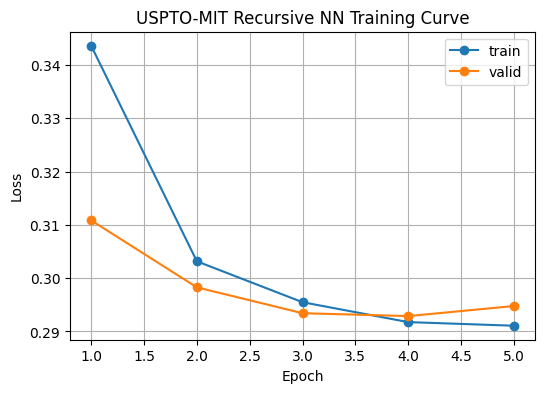

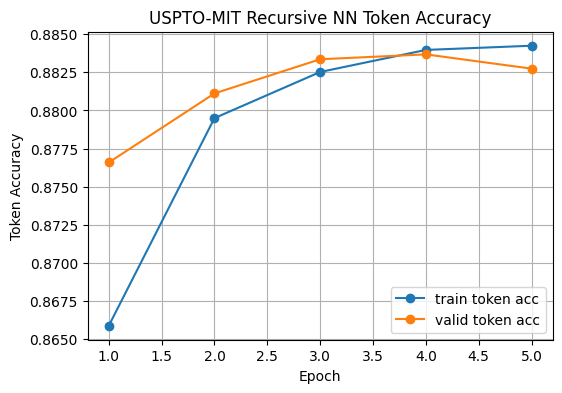

Run output directory: c:\Users\XQH\Desktop\274P project updated\outputs\uspto_mit_recursive_nn\recursive_nn_serious_tuned_final


In [14]:
hist_df = pd.DataFrame(history)
display(hist_df)

plt.figure(figsize=(6, 4))
plt.plot(hist_df["epoch"], hist_df["train_loss"], marker="o", label="train")
plt.plot(hist_df["epoch"], hist_df["valid_loss"], marker="o", label="valid")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("USPTO-MIT Recursive NN Training Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(hist_df["epoch"], hist_df["train_token_accuracy"], marker="o", label="train token acc")
plt.plot(hist_df["epoch"], hist_df["valid_token_accuracy"], marker="o", label="valid token acc")
plt.xlabel("Epoch")
plt.ylabel("Token Accuracy")
plt.title("USPTO-MIT Recursive NN Token Accuracy")
plt.legend()
plt.grid(True)
plt.show()

print("Run output directory:", RUN_OUTPUT_DIR)


## 14. Greedy decoding and exact-match evaluation

Exact match is strict: the predicted product SMILES must exactly match the target product SMILES.

For the report, use:

- validation loss
- token-level loss/perplexity
- exact-match accuracy
- examples of correct and incorrect predictions

In [15]:
@torch.no_grad()
def greedy_decode(model, src, max_len: int = 256):
    model.eval()
    src = src.to(DEVICE)
    batch_size = src.size(0)

    ys = torch.full((batch_size, 1), vocab.bos_id, dtype=torch.long, device=DEVICE)

    for _ in range(max_len - 1):
        logits = model(src, ys)
        next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)
        ys = torch.cat([ys, next_token], dim=1)

        if torch.all(next_token.squeeze(1).eq(vocab.eos_id)):
            break

    return ys


@torch.no_grad()
def evaluate_exact_match(model, dataset, n_examples: int = 100):
    model.eval()
    n = min(n_examples, len(dataset))
    rows = []
    exact = 0

    for i in tqdm(range(n), desc="Decoding"):
        src_ids, tgt_ids = dataset[i]
        src_batch = src_ids.unsqueeze(0)
        pred_ids = greedy_decode(model, src_batch, max_len=MAX_LEN)[0].cpu().tolist()

        src_text = vocab.decode(src_ids.tolist())
        tgt_text = vocab.decode(tgt_ids.tolist())
        pred_text = vocab.decode(pred_ids)

        is_exact = pred_text == tgt_text
        exact += int(is_exact)

        rows.append({
            "source": src_text,
            "target": tgt_text,
            "prediction": pred_text,
            "exact_match": is_exact,
        })

    return exact / max(n, 1), pd.DataFrame(rows)


N_DECODE_EXAMPLES = 100
exact_acc, pred_df = evaluate_exact_match(model, valid_ds, n_examples=N_DECODE_EXAMPLES)
print(f"Raw string exact-match accuracy on {N_DECODE_EXAMPLES} validation examples: {exact_acc:.4f}")

pred_df.head(10)

Decoding: 100%|██████████| 100/100 [01:42<00:00,  1.03s/it]

Raw string exact-match accuracy on 100 validation examples: 0.0000


,source,target,prediction,exact_match
0,[CH3][C](=[O])[CH3].[CH3][O][c]1[cH][cH][c]([S...,[CH3][O][c]1[cH][cH][c]([S](=[O])[O-])[cH][cH]...,[CH3][O][C]([CH2][CH2][CH2][CH2][CH2][CH2][CH2...,False
1,[CH3][C]([CH3])([O-])[CH3].[K+].[NH2][c]1[n][c...,[NH2][c]1[n][c]([O][CH2][c]2[n][cH][cH][cH][cH...,[CH3][O][C]([CH2][CH2][CH2][CH2][CH2][CH2][CH2...,False
2,[CH2]1[O][CH2][CH2][CH2]1.[CH3][c]1[cH][cH][c]...,[CH3][N]1[CH2][CH2][CH]([CH2][CH2][O][C]([N]2[...,[CH3][O][C]([CH2][CH2][CH2][CH2][CH2][CH2][CH2...,False
3,[C]([O][C](=[O])[N]1[CH2][CH2][CH]([CH2][O][C]...,[NH]1[CH2][CH2][CH]([CH2][O][C](=[O])[CH]2[N]3...,[CH3][O][C]([CH2][CH2][CH2][CH2][CH2][CH2][CH2...,False
4,[C]([c]1[cH][cH][cH][cH][cH]1)(=[O])[Cl].[CH2]...,[C]([c]1[cH][cH][cH][cH][cH]1)(=[O])[O][CH]1[C...,[CH3][O][C]([CH2][CH2][CH2][CH2][CH2][CH2][CH2...,False
5,[CH2]([CH3])[N]([CH2][CH2][N]([CH3])[CH2][c]1[...,[CH2]([CH3])[N]([CH2][CH2][N]([CH3])[CH2][c]1[...,[CH3][O][C]([CH2][CH2][CH2][CH2][CH2][CH2][CH2...,False
6,[CH3][c]1[cH][cH][c]([OH])[cH][cH]1.[Cl][c]1[n...,[CH3][c]1[cH][cH][c]([O][c]2[n][c]([NH][c]3[n]...,[CH3][O][C]([CH2][CH2][CH2][CH2][CH2][CH2][CH2...,False
7,[CH3][O][C]([CH]([CH3])[c]1[cH][cH][c]([C]#[C]...,[O]=[C]([CH]([CH3])[c]1[cH][cH][c]([C]#[C][c]2...,[CH3][O][C]([CH2][CH2][CH2][CH2][CH2][CH2][CH2...,False
8,[Cl][c]1[cH][cH][c]([O][c]2[cH][cH][cH][c]([N]...,[Cl][c]1[cH][cH][c]([O][c]2[cH][cH][cH][c]([N]...,[CH3][O][C]([CH2][CH2][CH2][CH2][CH2][CH2][CH2...,False
9,[CH3][CH2][NH2].[Na+].[OH-].[P]([O][c]1[cH][cH...,[c]1([NH][CH2][CH3])[cH][cH][cH][c]2[cH][cH][c...,[CH3][O][C]([CH2][CH2][CH2][CH2][CH2][CH2][CH2...,False


## 15. Chemical-equivalence evaluation with RDKit

Raw string exact match is very strict because the same molecule can sometimes be written using different valid SMILES strings. If RDKit is installed, this cell computes canonical-SMILES exact match. If RDKit is not installed, the cell safely falls back without crashing.

In [16]:
try:
    from rdkit import Chem
    RDKIT_AVAILABLE = True
except Exception as e:
    Chem = None
    RDKIT_AVAILABLE = False
    print("RDKit is not available. Chemical-equivalence evaluation will be skipped.")
    print("RDKit import error:", repr(e))


def canonicalize_smiles_components(smiles: str):
    """
    Canonicalize a possibly multi-product SMILES string.

    Why this matters:
    - Raw string exact match is too strict.
    - RDKit canonicalization counts equivalent SMILES forms as the same molecule.
    - Sorting components makes A.B equivalent to B.A for multi-molecule products.
    """
    if not RDKIT_AVAILABLE:
        return None
    if smiles is None:
        return None

    smiles = str(smiles).strip()
    if smiles == "" or smiles.lower() == "nan":
        return None

    # Remove atom mapping with the same regex used in preprocessing.
    smiles = strip_atom_mapping(smiles)

    canonical_components = []
    for comp in smiles.split("."):
        comp = comp.strip()
        if comp == "":
            continue

        mol = Chem.MolFromSmiles(comp)
        if mol is None:
            return None

        # Extra safety: remove atom map numbers if RDKit kept any.
        for atom in mol.GetAtoms():
            atom.SetAtomMapNum(0)

        canonical_components.append(Chem.MolToSmiles(mol, canonical=True))

    if not canonical_components:
        return None

    return ".".join(sorted(canonical_components))


def chemically_equivalent(prediction: str, target: str) -> bool:
    prediction_canonical = canonicalize_smiles_components(prediction)
    target_canonical = canonicalize_smiles_components(target)
    return prediction_canonical is not None and prediction_canonical == target_canonical


def chemical_equivalence_accuracy(predictions, targets):
    if not targets:
        return 0.0
    return sum(
        chemically_equivalent(pred, target)
        for pred, target in zip(predictions, targets)
    ) / len(targets)


def add_chemical_equivalence_columns(df: pd.DataFrame):
    if not RDKIT_AVAILABLE:
        print("Skipping chemical-equivalence evaluation because RDKit is not installed.")
        return df

    out = df.copy()
    out["target_canonical"] = out["target"].apply(canonicalize_smiles_components)
    out["prediction_canonical"] = out["prediction"].apply(canonicalize_smiles_components)
    out["prediction_valid_smiles"] = out["prediction_canonical"].notna()
    out["chemical_equivalence_match"] = (
        out["prediction_canonical"].notna()
        & out["target_canonical"].notna()
        & (out["prediction_canonical"] == out["target_canonical"])
    )

    chemical_equiv_acc = out["chemical_equivalence_match"].mean()
    valid_smiles_rate = out["prediction_valid_smiles"].mean()

    print(f"Chemical-equivalence accuracy on decoded examples: {chemical_equiv_acc:.4f}")
    print(f"Valid predicted SMILES rate on decoded examples: {valid_smiles_rate:.4f}")
    return out


pred_eval_df = add_chemical_equivalence_columns(pred_df)

slide_metrics = {
    "model": "Recursive NN seq2seq",
    "tuning": "Ray Tune",
    "learning_rate": CONFIG["learning_rate"],
    "dropout": CONFIG["dropout"],
    "batch_size": CONFIG["batch_size"],
    "best_valid_loss": min([row["valid_loss"] for row in history]) if history else None,
    "best_valid_token_accuracy": max([row["valid_token_accuracy"] for row in history]) if history else None,
    "raw_exact_match_accuracy": float(pred_eval_df["exact_match"].mean()) if "exact_match" in pred_eval_df else None,
    "chemical_equivalence_accuracy": float(pred_eval_df["chemical_equivalence_match"].mean()) if "chemical_equivalence_match" in pred_eval_df else None,
    "valid_predicted_smiles_rate": float(pred_eval_df["prediction_valid_smiles"].mean()) if "prediction_valid_smiles" in pred_eval_df else None,
}

slide_metrics_df = pd.DataFrame([slide_metrics])
display(slide_metrics_df)
slide_metrics_df.to_csv(RUN_OUTPUT_DIR / "slide_metrics.csv", index=False)
print("Saved slide metrics to:", RUN_OUTPUT_DIR / "slide_metrics.csv")

pred_eval_df.head(10)


RDKit is not available. Chemical-equivalence evaluation will be skipped.
RDKit import error: ModuleNotFoundError("No module named 'rdkit'")
Skipping chemical-equivalence evaluation because RDKit is not installed.


,model,tuning,learning_rate,dropout,batch_size,best_valid_loss,best_valid_token_accuracy,raw_exact_match_accuracy,chemical_equivalence_accuracy,valid_predicted_smiles_rate
0,Recursive NN seq2seq,Ray Tune,0.000858,0.08759,32,0.292885,0.883683,0.0,None,None


Saved slide metrics to: c:\Users\XQH\Desktop\274P project updated\outputs\uspto_mit_recursive_nn\recursive_nn_serious_tuned_final\slide_metrics.csv


,source,target,prediction,exact_match
0,[CH3][C](=[O])[CH3].[CH3][O][c]1[cH][cH][c]([S...,[CH3][O][c]1[cH][cH][c]([S](=[O])[O-])[cH][cH]...,[CH3][O][C]([CH2][CH2][CH2][CH2][CH2][CH2][CH2...,False
1,[CH3][C]([CH3])([O-])[CH3].[K+].[NH2][c]1[n][c...,[NH2][c]1[n][c]([O][CH2][c]2[n][cH][cH][cH][cH...,[CH3][O][C]([CH2][CH2][CH2][CH2][CH2][CH2][CH2...,False
2,[CH2]1[O][CH2][CH2][CH2]1.[CH3][c]1[cH][cH][c]...,[CH3][N]1[CH2][CH2][CH]([CH2][CH2][O][C]([N]2[...,[CH3][O][C]([CH2][CH2][CH2][CH2][CH2][CH2][CH2...,False
3,[C]([O][C](=[O])[N]1[CH2][CH2][CH]([CH2][O][C]...,[NH]1[CH2][CH2][CH]([CH2][O][C](=[O])[CH]2[N]3...,[CH3][O][C]([CH2][CH2][CH2][CH2][CH2][CH2][CH2...,False
4,[C]([c]1[cH][cH][cH][cH][cH]1)(=[O])[Cl].[CH2]...,[C]([c]1[cH][cH][cH][cH][cH]1)(=[O])[O][CH]1[C...,[CH3][O][C]([CH2][CH2][CH2][CH2][CH2][CH2][CH2...,False
5,[CH2]([CH3])[N]([CH2][CH2][N]([CH3])[CH2][c]1[...,[CH2]([CH3])[N]([CH2][CH2][N]([CH3])[CH2][c]1[...,[CH3][O][C]([CH2][CH2][CH2][CH2][CH2][CH2][CH2...,False
6,[CH3][c]1[cH][cH][c]([OH])[cH][cH]1.[Cl][c]1[n...,[CH3][c]1[cH][cH][c]([O][c]2[n][c]([NH][c]3[n]...,[CH3][O][C]([CH2][CH2][CH2][CH2][CH2][CH2][CH2...,False
7,[CH3][O][C]([CH]([CH3])[c]1[cH][cH][c]([C]#[C]...,[O]=[C]([CH]([CH3])[c]1[cH][cH][c]([C]#[C][c]2...,[CH3][O][C]([CH2][CH2][CH2][CH2][CH2][CH2][CH2...,False
8,[Cl][c]1[cH][cH][c]([O][c]2[cH][cH][cH][c]([N]...,[Cl][c]1[cH][cH][c]([O][c]2[cH][cH][cH][c]([N]...,[CH3][O][C]([CH2][CH2][CH2][CH2][CH2][CH2][CH2...,False
9,[CH3][CH2][NH2].[Na+].[OH-].[P]([O][c]1[cH][cH...,[c]1([NH][CH2][CH3])[cH][cH][cH][c]2[cH][cH][c...,[CH3][O][C]([CH2][CH2][CH2][CH2][CH2][CH2][CH2...,False


## 16. Save prediction examples

This saves the decoded examples for the report. These examples are useful for qualitative analysis: where the model copies parts of the reactants, where it produces invalid SMILES, and where it predicts the correct product.

In [17]:
pred_csv_path = RUN_OUTPUT_DIR / "recursive_nn_validation_predictions.csv"
pred_eval_df.to_csv(pred_csv_path, index=False)
print("Saved predictions to:", pred_csv_path)


Saved predictions to: c:\Users\XQH\Desktop\274P project updated\outputs\uspto_mit_recursive_nn\recursive_nn_serious_tuned_final\recursive_nn_validation_predictions.csv
